<a href="https://colab.research.google.com/github/negrete-93/Ecuacion-de-Onda-Metodo-explicito/blob/main/Ecuaci%C3%B3n_de_onda_M%C3%A9todo_expl%C3%ADcito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ecuacón de onda: Método explícito

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.animation as animation


In [31]:
L = 1
N = 9 # Numero de incognitas internas
Tmax = 0.5 # Tiempo maximo de simulacion

alpha = 2
h = L / (N+1) # Tamanio de la malla espacial

ht = 0.05 # Paso de tiempo
lamb = alpha * ht / h

In [35]:
print(f"h = {h:.5f}, ht = {ht:.5f}, lambda = {lamb:.5f}")
if lamb > 1.0:
    print("lambda > 1 -> esquema inestable. Reduce ht o aumenta N_interior.")

h = 0.10000, ht = 0.05000, lambda = 1.00000


In [37]:
Nt = int(Tmax / ht) # Numero total de pasos
Tmax = Nt * ht # Tiempo total de simulacion
times = np.linspace(0,Tmax,Nt+1)

# malla espacial con nodos de frontera incluidos
x = np.linspace(0, L, N+ 2)  # tamaño N_interior+2

In [38]:
#Condiciones iniciales
def f(x):
  return np.sin(np.pi * x)

In [39]:
def g(x):
  return 0

In [55]:
def solExacta(x, t):
  return np.sin(np.pi * x) * np.cos(alpha * np.pi * t)

In [43]:
#Inicializamos los Arrays e incluimos fronteras
u_nm1 = np.zeros_like(x)
u_n   = f(x).copy()
u_np1 = np.zeros_like(x)

# Calcula u^1 (primer paso) usando fórmula centrada en el tiempo

u_nm1[:] = u_n.copy()  # guardamos u^0 en u^{n-1} para la iteración
u_np1[:] = 0.0

for i in range(1, len(x)-1):
    u_np1[i] = (1 - lamb**2) * u_n[i] + 0.5 * lamb **2 * (u_n[i+1] + u_n[i-1]) + ht * g(x[i])

# Imponemos fronteras
u_np1[0] = 0.0
u_np1[-1] = 0.0

# Ahora actualizamos: queremos que u_nm1 = u^0, u_n = u^1 para entrar al bucle general
u_nm1 = u_n.copy()
u_n = u_np1.copy()

# almacenamos soluciones en todos los tiempos para posterior plotting/animación
U = np.zeros((Nt+1, len(x)))
U[0, :] = f(x)
U[1, :] = u_n.copy()


In [46]:
# Bucle temporal (esquema central)
# -----------------------
for n in range(1, Nt):
    # calcular u^{n+1}
    u_np1 = np.zeros_like(x)
    for i in range(1, len(x)-1):
        u_np1[i] = (2 * u_n[i] - u_nm1[i] +
                    lamb**2 * (u_n[i+1] - 2*u_n[i] + u_n[i-1]) )

    # fronteras Dirichlet
    u_np1[0] = 0.0
    u_np1[-1] = 0.0


    #Almacenamos
    U[n+1, :] = u_n

Ejercicio 1: Generar las gráficas 2D y 3D de la solución hasta t=0.50

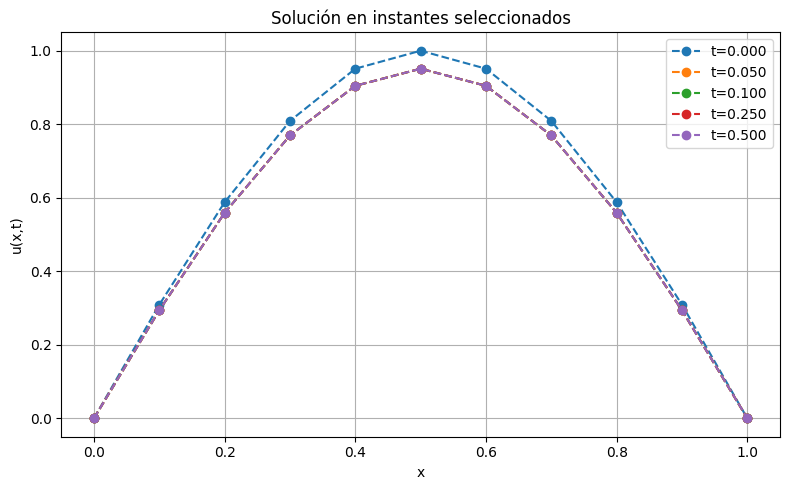

In [47]:
tiempos_mostrar = [0.0, 0.05, 0.1, 0.25, 0.5]  # añade los tiempos que quieras (<=Tmax)
indices = [int(np.round(t / ht)) for t in tiempos_mostrar if t <= Tmax]

plt.figure(figsize=(8,5))
for idx in indices:
    plt.plot(x, U[idx,:], marker='o', linestyle='--', label=f"t={idx*ht:.3f}")
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Solución en instantes seleccionados')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('sol_2D_instantes.png', dpi=150)


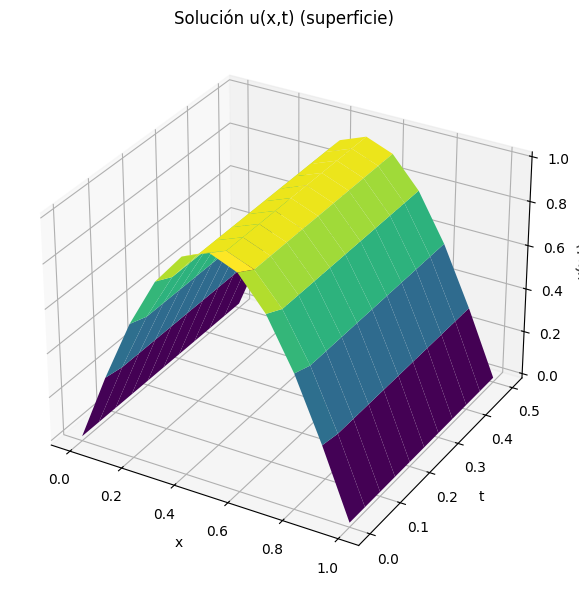

In [48]:

# 3D: superficie x-t
X, T = np.meshgrid(x, times)
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T, U, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x,t)')
ax.set_title('Solución u(x,t) (superficie)')
plt.tight_layout()
plt.savefig('sol_3D_surface.png', dpi=150)

Ejercicio 2: Comparar los valores correspondientes su solución numérica con los resultados numéricos que proporciona la Tabla 12.6, que viene en la imagen adjunta. Graficar y calcular el error.

In [49]:
x_tabla = np.array([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
w_tabla = np.array([
    0.000000,
    0.3090169944,
    0.5877852523,
    0.8090169944,
    0.9510565163,
    1.000000,
    0.9510565163,
    0.8090169944,
    0.5877852523,
    0.3090169944,
    0.000000000
])

In [51]:
# Tiempo correspondiente
n_tabla = Nt # Corrected from 20 to Nt (which is 10)
t_tabla = n_tabla * ht

# Interpolación de la solución numérica en los puntos de la tabla
w_interp = np.interp(x_tabla, x, U[n_tabla, :])

# Error
error_tabla = np.abs(w_interp - w_tabla)


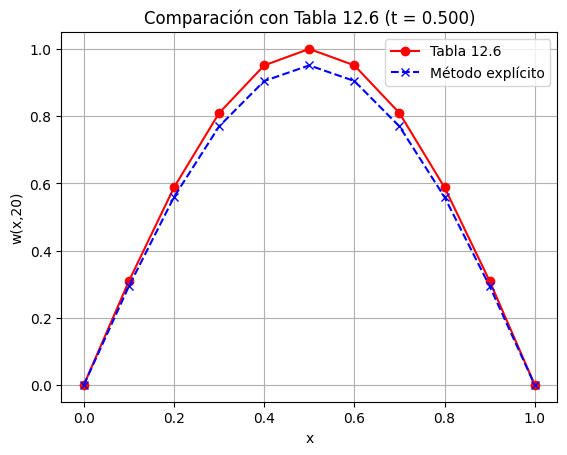

In [52]:
#Gráfica comparativa
plt.figure()
plt.plot(x_tabla, w_tabla, 'ro-', label='Tabla 12.6')
plt.plot(x_tabla, w_interp, 'bx--', label='Método explícito')
plt.xlabel('x')
plt.ylabel('w(x,20)')
plt.title(f'Comparación con Tabla 12.6 (t = {t_tabla:.3f})')
plt.legend()
plt.grid(True)
plt.show()


In [53]:
#Errores
print("x        Tabla        Numérico      Error")
for i in range(len(x_tabla)):
    print(f"{x_tabla[i]:.1f}   {w_tabla[i]:.8f}   {w_interp[i]:.8f}   {error_tabla[i]:.2e}")

# Error global
print("\nError infinito:", np.max(error_tabla))
print("Error L2:", np.sqrt(np.sum(error_tabla**2)))

x        Tabla        Numérico      Error
0.0   0.00000000   0.00000000   0.00e+00
0.1   0.30901699   0.29389263   1.51e-02
0.2   0.58778525   0.55901699   2.88e-02
0.3   0.80901699   0.76942088   3.96e-02
0.4   0.95105652   0.90450850   4.65e-02
0.5   1.00000000   0.95105652   4.89e-02
0.6   0.95105652   0.90450850   4.65e-02
0.7   0.80901699   0.76942088   3.96e-02
0.8   0.58778525   0.55901699   2.88e-02
0.9   0.30901699   0.29389263   1.51e-02
1.0   0.00000000   0.00000000   0.00e+00

Error infinito: 0.04894348370484647
Error L2: 0.10944095665282214


  Ejercicio 3: Comparar esos mismos valores contra la solución exacta de la ecuación. Graficar y calcular el error. Discutir la comparación.

In [57]:
# Comparación con la solución exacta
w_exacta = solExacta(x_tabla, t_tabla)

error_exacto = np.abs(w_interp - w_exacta)

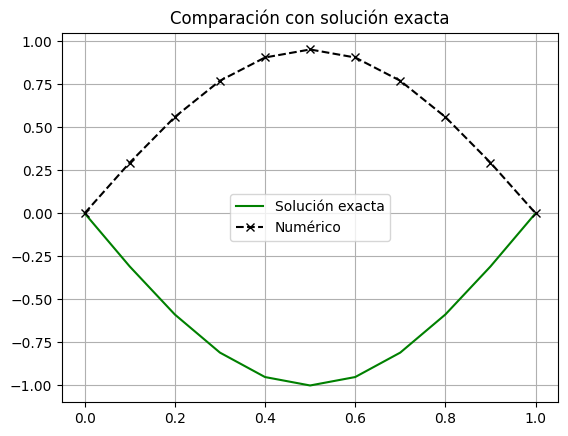

In [58]:
#Gráfica comparativa
plt.figure()
plt.plot(x_tabla, w_exacta, 'g-', label='Solución exacta')
plt.plot(x_tabla, w_interp, 'kx--', label='Numérico')
plt.legend()
plt.title("Comparación con solución exacta")
plt.grid()
plt.show()

In [59]:
#Comparación
print("\nComparación con solución exacta")
print("Error infinito:", np.max(error_exacto))
print("Error L2:", np.sqrt(np.sum(error_exacto**2)))


Comparación con solución exacta
Error infinito: 1.9510565162951536
Error L2: 4.362694998379889


Ejercicio 4: Genere una animación de la evolución temporal de la solución, donde efectivamente se observen las ondulaciones de la onda.

NameError: name 'os' is not defined

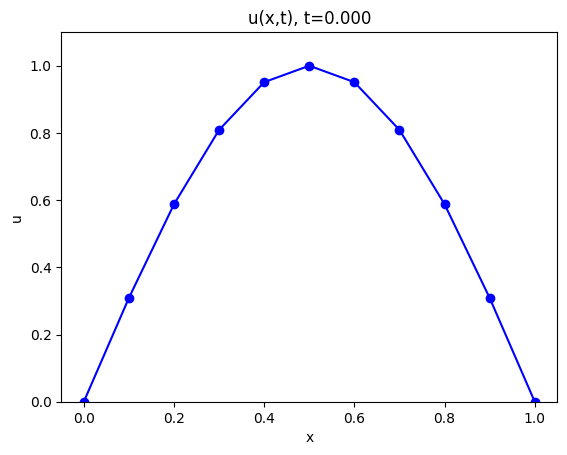

In [64]:
fig2, ax2 = plt.subplots()
line, = ax2.plot(x, U[0,:], 'b-o')
ax2.set_ylim(1.1 * U.min(), 1.1 * U.max())
ax2.set_xlabel('x')
ax2.set_ylabel('u')
ax2.set_title('Evolución temporal de u(x,t)')

def animate(k):
    line.set_data(x, U[k,:])
    ax2.set_title(f'u(x,t), t={k*ht:.3f}')
    return (line,)

ani = animation.FuncAnimation(fig2, animate, frames=U.shape[0], interval=30, blit=True)

# guardar animación (recomendado ffmpeg instalado) o gif
out_dir = 'output'
os.makedirs(out_dir, exist_ok=True)
ani.save(os.path.join(out_dir, 'onda_evolucion.mp4'), writer='ffmpeg', fps=30)
ani.save(os.path.join(out_dir, 'onda_evolucion.gif'), writer='pillow', fps=30)

print("Gráficas y animación generadas en el directorio 'output' o en los ficheros guardados arriba.")
plt.close('all')

In [66]:
def animate(k):
    line.set_data(x, U[k,:])
    ax2.set_title(f'u(x,t), t={k*ht:.3f}')
    return (line,)

ani = animation.FuncAnimation(fig2, animate, frames=U.shape[0], interval=30, blit=True)

# guardamos
out_dir = 'output'
os.makedirs(out_dir, exist_ok=True)
ani.save(os.path.join(out_dir, 'onda_evolucion.mp4'), writer='ffmpeg', fps=30)
ani.save(os.path.join(out_dir, 'onda_evolucion.gif'), writer='pillow', fps=30)

print("Gráficas y animación generadas en el directorio 'output' o en los ficheros guardados arriba.")
plt.close('all')

Gráficas y animación generadas en el directorio 'output' o en los ficheros guardados arriba.
